# Experiment 6: Test-Time Augmentation + Query Expansion for Jaguar Re-Identification

**Research Question:** Can Test-Time Augmentation (TTA) and Average Query Expansion (AQE) applied to a freshly trained frozen model at inference time improve identity-balanced mAP without any additional GPU training?

## Overview

1. **Data Loading**: Stratified train/validation split ensuring all identities appear in both sets
2. **Backbone + Embedding Extraction**: Freeze MegaDescriptor-L-384, extract and cache embeddings
3. **Model Training**: Train ArcFace projection head, save best checkpoint to disk
4. **Baseline Inference**: Single-pass mAP with no TTA or AQE
5. **TTA Ablation**: Average embeddings across N augmented views (N = 1, 4, 8)
6. **AQE Ablation**: Expand each query with its top-k retrieved neighbours
7. **Combined TTA + AQE**: Test whether gains are additive
8. **Analysis**: Per-identity gains, inference cost, mAP vs compute tradeoff
9. **Submission**: Best configuration applied to test set

## Conditions Compared

| Condition | TTA Views | Query Expansion | Expected Benefit |
|---|---|---|---|
| **Baseline** | 1 | None | Reference — single-pass inference |
| **TTA-4** | 4 | None | Reduces single-view noise |
| **TTA-8** | 8 | None | More robust, higher cost |
| **AQE-k5** | 1 | top-5, α=1.0 | Pulls query toward match cluster |
| **AQE-k10** | 1 | top-10, α=1.0 | Wider neighbourhood expansion |
| **TTA-4 + AQE-k5** | 4 | top-5, α=1.0 | Combined — test if additive |
| **TTA-8 + AQE-k10** | 8 | top-10, α=1.0 | Maximum quality |

## Controlled Variables
- Backbone: **MegaDescriptor-L-384** (frozen throughout)
- Projection head: Linear(1536 → 512 → 256), BatchNorm, ReLU, Dropout(0.3)
- Loss: ArcFace (margin=0.5, scale=64)
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Epochs: 50, Batch size: 32, Seed: 42


## 1. Setup and Configuration

In [1]:
import os
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device: cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [2]:
RANDOM_SEED = 42

# TTA and AQE configs to ablate (used after training)
TTA_CONFIGS = [1, 4, 8]
AQE_CONFIGS = [
    {"k": 0,  "alpha": 0.0},   # no expansion — baseline
    {"k": 5,  "alpha": 1.0},
    {"k": 10, "alpha": 1.0},
]

config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Backbone (frozen)
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size":           384,

    # Projection head
    "embedding_dim":  256,
    "hidden_dim":     512,
    "dropout":        0.3,

    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale":  64.0,

    # Training
    "batch_size":     32,
    "learning_rate":  1e-4,
    "weight_decay":   1e-4,
    "num_epochs":     50,
    "patience":       10,
    "val_split":      0.2,
    "seed":           RANDOM_SEED,
}

config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = config["checkpoint_dir"] / "megadescriptor_arcface_best.pth"

print("TTA + AQE Configuration:")
print(f"  Backbone:        {config['megadescriptor_model']}")
print(f"  Embedding dim:   {config['embedding_dim']}")
print(f"  ArcFace margin:  {config['arcface_margin']}, scale: {config['arcface_scale']}")
print(f"  Epochs:          {config['num_epochs']}, patience: {config['patience']}")
print(f"  Checkpoint path: {CHECKPOINT_PATH}")
print(f"  TTA views:       {TTA_CONFIGS}")
print(f"  AQE configs:     {AQE_CONFIGS}")


Q6 TTA + AQE Configuration:
  Backbone:        hf-hub:BVRA/MegaDescriptor-L-384
  Embedding dim:   256
  ArcFace margin:  0.5, scale: 64.0
  Epochs:          50, patience: 10
  Checkpoint path: /kaggle/working/checkpoints/megadescriptor_arcface_best.pth
  TTA views:       [1, 4, 8]
  AQE configs:     [{'k': 0, 'alpha': 0.0}, {'k': 5, 'alpha': 1.0}, {'k': 10, 'alpha': 1.0}]


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":        "tta-aqe",
        "backbone":          config["megadescriptor_model"],
        "embedding_dim":     config["embedding_dim"],
        "hidden_dim":        config["hidden_dim"],
        "dropout":           config["dropout"],
        "arcface_margin":    config["arcface_margin"],
        "arcface_scale":     config["arcface_scale"],
        "batch_size":        config["batch_size"],
        "learning_rate":     config["learning_rate"],
        "weight_decay":      config["weight_decay"],
        "num_epochs":        config["num_epochs"],
        "patience":          config["patience"],
        "val_split":         config["val_split"],
        "seed":              config["seed"],
        "tta_views_tested":  TTA_CONFIGS,
        "aqe_configs":       AQE_CONFIGS,
    },
    name="tta-aqe",
)
print("W&B run initialised: tta-aqe")
print("  Training metrics  → training/")
print("  TTA+AQE ablation  → {condition}/")
print("  Final results     → results/")


W&B run initialised: tta-aqe-q6
  Training metrics  → training/
  TTA+AQE ablation  → {condition}/
  Final results     → results/


## 2. Load and Prepare Data

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images:      {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min:  {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max:  {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean: {identity_counts.mean():.1f}")


Training dataset:
  Total images:      1895
  Unique identities: 31

Sample rows:
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min:  13 (Ipepo)
  Max:  183 (Marcela)
  Mean: 61.1


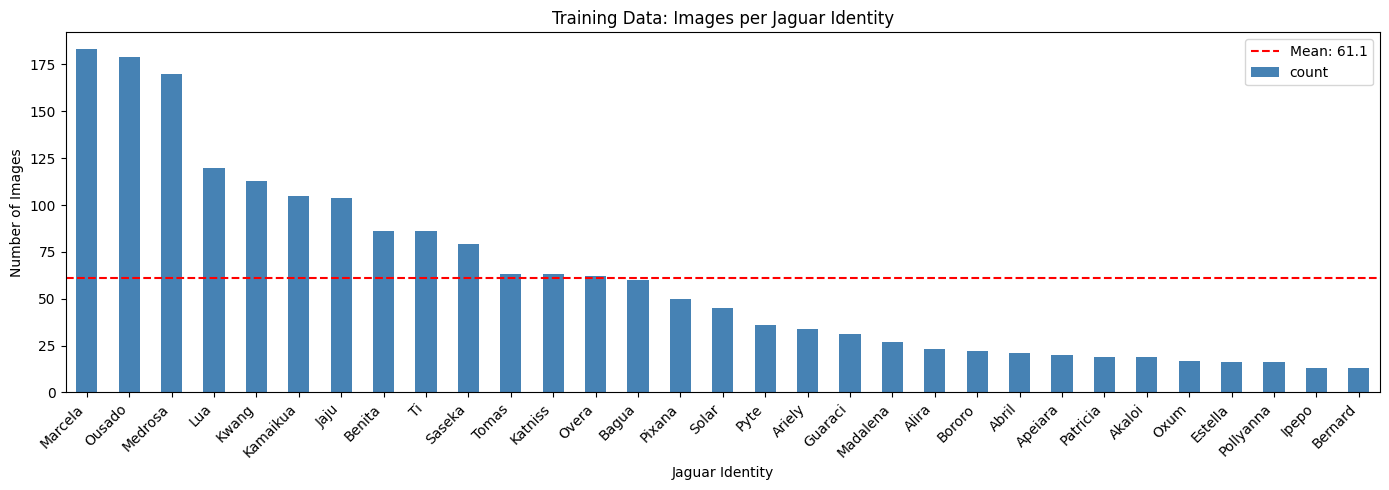

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--',
           label=f'Mean: {identity_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
wandb.log({"identity_distribution_full": wandb.Image(fig)})
plt.show()


In [7]:
# Stratified split — identical seed to all prior experiments
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size    = config["val_split"],
    random_state = config["seed"],
    stratify     = train_df['ground_truth'],
)

train_identities = set(train_data['ground_truth'].unique())
val_identities   = set(val_data['ground_truth'].unique())

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")
print(f"  Identities in both sets: {len(train_identities & val_identities)} / {num_classes}")
assert train_identities == val_identities, "Some identities missing from val!"
print("  All identities present in both sets ✓")

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config["data_dir"] / "train/train" / fn
               for fn in train_data["filename"].astype(str)]
val_paths   = [config["data_dir"] / "train/train" / fn
               for fn in val_data["filename"].astype(str)]

train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts   = val_data['ground_truth'].value_counts().sort_index()

distribution_df = pd.DataFrame({
    'identity':    train_counts.index,
    'train_count': train_counts.values,
    'val_count':   val_counts.values,
})
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities":  num_classes,
    "train_samples":   len(train_data),
    "val_samples":     len(val_data),
})


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Identities in both sets: 31 / 31
  All identities present in both sets ✓


## 3. Load MegaDescriptor Backbone

MegaDescriptor-L-384 is a ViT-L backbone pretrained on wildlife re-identification
datasets. It produces 1536-dimensional embeddings. The backbone is **fully frozen**
throughout — all training updates go only to the projection head.


In [8]:
print("Loading MegaDescriptor-L-384...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained  = True,
    num_classes = 0,
    img_size    = config["input_size"],
)
megadescriptor.eval()
for p in megadescriptor.parameters():
    p.requires_grad = False
megadescriptor.to(device)

with torch.no_grad():
    dummy = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    megadescriptor_dim = megadescriptor(dummy).shape[1]

print(f"  Embedding dim: {megadescriptor_dim}")
print(f"  Parameters:    {sum(p.numel() for p in megadescriptor.parameters()):,}")
print(f"  Frozen:        True (no gradient updates)")


Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Embedding dim: 1536
  Parameters:    195,198,516
  Frozen:        True (no gradient updates)


In [9]:
# Standard preprocessing (used for training-time embedding extraction)
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"Preprocessing: Resize({config['input_size']}x{config['input_size']}) → ToTensor → ImageNet Normalize")


Preprocessing: Resize(384x384) → ToTensor → ImageNet Normalize


In [10]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32,
                        desc="Extracting embeddings"):
    """Extract (N, D) embeddings from a frozen backbone using standard preprocessing."""
    model.eval()
    all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        tensors = []
        for p in batch_paths:
            try:
                tensors.append(preprocess(Image.open(p).convert("RGB")))
            except Exception as e:
                print(f"  [WARN] {p}: {e}")
                tensors.append(torch.zeros(3, config["input_size"],
                                           config["input_size"]))
        all_embs.append(
            model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)

print("extract_embeddings defined.")


extract_embeddings defined.


In [11]:
# Train embeddings
tr_cache = config["cache_dir"] / "megadesc_train_embeddings.npz"
if tr_cache.exists():
    baseline_train_embeddings = np.load(tr_cache)["embeddings"]
    print(f"Loaded cached train embeddings: {baseline_train_embeddings.shape}")
else:
    print(f"Extracting train embeddings for {len(train_paths)} images...")
    baseline_train_embeddings = extract_embeddings(
        megadescriptor, train_paths,
        batch_size=config["batch_size"], desc="Train embeddings")
    np.savez_compressed(tr_cache, embeddings=baseline_train_embeddings)
    print(f"Saved to {tr_cache}: {baseline_train_embeddings.shape}")

# Val embeddings
va_cache = config["cache_dir"] / "megadesc_val_embeddings.npz"
if va_cache.exists():
    baseline_val_embeddings = np.load(va_cache)["embeddings"]
    print(f"Loaded cached val embeddings:   {baseline_val_embeddings.shape}")
else:
    print(f"Extracting val embeddings for {len(val_paths)} images...")
    baseline_val_embeddings = extract_embeddings(
        megadescriptor, val_paths,
        batch_size=config["batch_size"], desc="Val embeddings")
    np.savez_compressed(va_cache, embeddings=baseline_val_embeddings)
    print(f"Saved to {va_cache}: {baseline_val_embeddings.shape}")


Extracting train embeddings for 1516 images...


Train embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved to /kaggle/working/embeddings/megadesc_train_embeddings.npz: (1516, 1536)
Extracting val embeddings for 379 images...


Val embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Saved to /kaggle/working/embeddings/megadesc_val_embeddings.npz: (379, 1536)


## 4. Visualise Baseline Embeddings

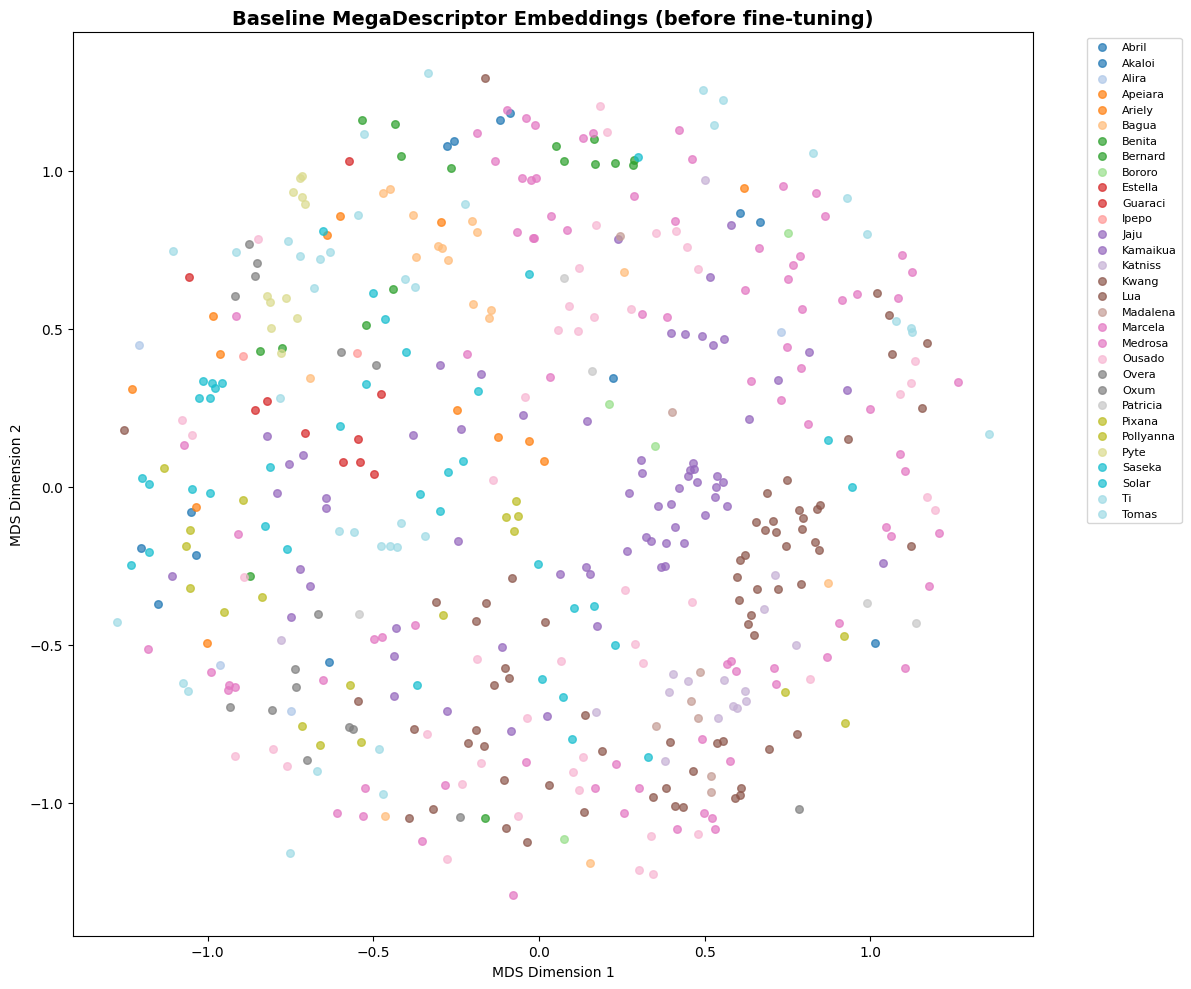

In [12]:
from sklearn.manifold import MDS

def compute_geodesic_distances(embeddings):
    norms      = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    cos_sim    = np.clip(normalized @ normalized.T, -1.0, 1.0)
    return np.arccos(cos_sim)

def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    if len(embeddings) > max_samples:
        idx        = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[idx]; labels = labels[idx]
    dist_matrix  = compute_geodesic_distances(embeddings)
    mds          = MDS(n_components=2, dissimilarity='precomputed',
                       random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d    = mds.fit_transform(dist_matrix)
    unique_labels = np.unique(labels)
    colors        = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {l: colors[i] for i, l in enumerate(unique_labels)}
    fig, ax = plt.subplots(figsize=(12, 10))
    for label in unique_labels:
        mask = labels == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   c=[label_to_color[label]], label=label, alpha=0.7, s=30)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1'); ax.set_ylabel('MDS Dimension 2')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    return fig

train_labels = train_data['ground_truth'].values
fig_baseline = visualize_embeddings_mds(
    baseline_train_embeddings, train_labels,
    "Baseline MegaDescriptor Embeddings (before fine-tuning)")
wandb.log({"baseline_embeddings_mds": wandb.Image(fig_baseline)})
plt.show()


## 5. Define Model Architecture

In [14]:
class EmbeddingProjection(nn.Module):
    """Linear → BN → ReLU → Dropout → Linear → BN."""    
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.net(x)


class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(
            1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes, embedding_dim=256,
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim,
                                               embedding_dim, dropout)
        self.arcface    = ArcFaceHead(embedding_dim, num_classes,
                                      margin=margin, scale=scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


# Sanity check
_m = ArcFaceModel(input_dim=megadescriptor_dim, num_classes=num_classes).to(device)
_x = torch.randn(4, megadescriptor_dim).to(device)
_l = torch.zeros(4, dtype=torch.long).to(device)
_logits, _emb = _m(_x, _l)
print(f"ArcFaceModel sanity check: logits={_logits.shape}, emb={_emb.shape}")
del _m, _x, _l, _logits, _emb
print("Model architecture ready.")


ArcFaceModel sanity check: logits=torch.Size([4, 31]), emb=torch.Size([4, 256])
Model architecture ready.


## 6. Prepare DataLoaders

In [16]:
class EmbeddingDataset(Dataset):
    """Dataset wrapping pre-extracted embeddings and integer labels."""    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):           return len(self.labels)
    def __getitem__(self, idx):  return self.embeddings[idx], self.labels[idx]


train_dataset = EmbeddingDataset(baseline_train_embeddings, train_labels_enc)
val_dataset   = EmbeddingDataset(baseline_val_embeddings,   val_labels_enc)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"],
                           shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=config["batch_size"],
                           shuffle=False, num_workers=0, pin_memory=True)

print(f"Train loader: {len(train_loader)} batches ({len(train_dataset)} samples)")
print(f"Val loader:   {len(val_loader)} batches ({len(val_dataset)} samples)")


Train loader: 48 batches (1516 samples)
Val loader:   12 batches (379 samples)


## 7. Training Setup

In [17]:
def compute_validation_map(model, val_embeddings, val_labels):
    """Identity-balanced mAP using the model's fine-tuned embeddings."""    
    model.eval()
    with torch.no_grad():
        emb = model.get_embeddings(
            torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, val_labels)


def _map_from_embeddings(emb, labels):
    """Identity-balanced mAP from a numpy embedding matrix."""    
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim[q]); sm = is_match[order]
        cum      = np.cumsum(sm)
        prec     = cum / np.arange(1, len(sm) + 1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


print(" Training Setup:")
print(f"  Loss:      CrossEntropyLoss (over ArcFace logits)")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, "
      f"weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Epochs:    {config['num_epochs']}, patience: {config['patience']}")
print(f"  Checkpoint saved to: {CHECKPOINT_PATH}")


 Training Setup:
  Loss:      CrossEntropyLoss (over ArcFace logits)
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Epochs:    50, patience: 10
  Checkpoint saved to: /kaggle/working/checkpoints/megadescriptor_arcface_best.pth


## 8. Training Loop

In [18]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Training', leave=False)
    for emb, labels in pbar:
        emb, labels = emb.to(device), labels.to(device)
        logits, _   = model(emb, labels)
        loss        = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total:.1f}%")
    return total_loss / len(loader), 100. * correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for emb, labels in pbar:
            emb, labels = emb.to(device), labels.to(device)
            logits, _   = model(emb, labels)
            loss        = criterion(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             acc=f"{100.*correct/total:.1f}%")
    return total_loss / len(loader), 100. * correct / total


# Initialise model, optimiser, scheduler
set_seed(config["seed"])
model = ArcFaceModel(
    input_dim     = megadescriptor_dim,
    num_classes   = num_classes,
    embedding_dim = config["embedding_dim"],
    hidden_dim    = config["hidden_dim"],
    margin        = config["arcface_margin"],
    scale         = config["arcface_scale"],
    dropout       = config["dropout"],
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=config["learning_rate"],
                               weight_decay=config["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

history = {k: [] for k in
           ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_map', 'lr']}
best_val_loss    = float('inf')
best_map         = 0.0
best_epoch       = 0
patience_counter = 0

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Starting training for {config['num_epochs']} epochs...")
print()

# Main training loop
for epoch in range(config['num_epochs']):
    train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                         optimizer, device)
    val_loss, val_acc     = validate_epoch(model, val_loader, criterion, device)
    val_map               = compute_validation_map(
                                model, baseline_val_embeddings, val_labels_str)
    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(lr)

    wandb.log({
        "training/epoch":      epoch + 1,
        "training/train_loss": train_loss,
        "training/train_acc":  train_acc,
        "training/val_loss":   val_loss,
        "training/val_acc":    val_acc,
        "training/val_map":    val_map,
        "training/lr":         lr,
    })

    print(f"  Epoch {epoch+1:3d}/{config['num_epochs']} | "
          f"TrLoss: {train_loss:.4f} | VaLoss: {val_loss:.4f} | "
          f"VaAcc: {val_acc:.1f}% | VamAP: {val_map:.4f} | LR: {lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_map         = val_map
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save({
            'epoch':            best_epoch,
            'model_state_dict': model.state_dict(),
            'val_loss':         float(best_val_loss),
            'val_map':          float(best_map),
            'megadescriptor_dim': megadescriptor_dim,
            'num_classes':      num_classes,
            'config':           {k: str(v) if isinstance(v, Path) else v
                                 for k, v in config.items()},
        }, CHECKPOINT_PATH)
        print(f"    ✓ Saved best checkpoint "
              f"(epoch {best_epoch}, mAP={best_map:.4f}) → {CHECKPOINT_PATH}")
    else:
        patience_counter += 1
        if patience_counter >= config['patience']:
            print(f"  Early stopping at epoch {epoch+1} "
                  f"(patience={config['patience']})")
            break

wandb.log({
    "training/best_val_map":  best_map,
    "training/best_epoch":    best_epoch,
    "training/best_val_loss": best_val_loss,
})
print(f"\nTraining complete.")
print(f"  Best val mAP: {best_map:.4f} @ epoch {best_epoch}")
print(f"  Checkpoint:   {CHECKPOINT_PATH}")


Model parameters: 927,744
Starting training for 50 epochs...



Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch   1/50 | TrLoss: 36.5123 | VaLoss: 31.5810 | VaAcc: 0.0% | VamAP: 0.3339 | LR: 1.00e-04
    ✓ Saved best checkpoint (epoch 1, mAP=0.3339) → /kaggle/working/checkpoints/megadescriptor_arcface_best.pth


Training:   0%|          | 0/48 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  49/50 | TrLoss: 0.8027 | VaLoss: 4.7294 | VaAcc: 82.6% | VamAP: 0.7737 | LR: 1.00e-04
    ✓ Saved best checkpoint (epoch 49, mAP=0.7737) → /kaggle/working/checkpoints/megadescriptor_arcface_best.pth


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  50/50 | TrLoss: 0.7703 | VaLoss: 4.6852 | VaAcc: 83.6% | VamAP: 0.7748 | LR: 1.00e-04
    ✓ Saved best checkpoint (epoch 50, mAP=0.7748) → /kaggle/working/checkpoints/megadescriptor_arcface_best.pth

Training complete.
  Best val mAP: 0.7748 @ epoch 50
  Checkpoint:   /kaggle/working/checkpoints/megadescriptor_arcface_best.pth


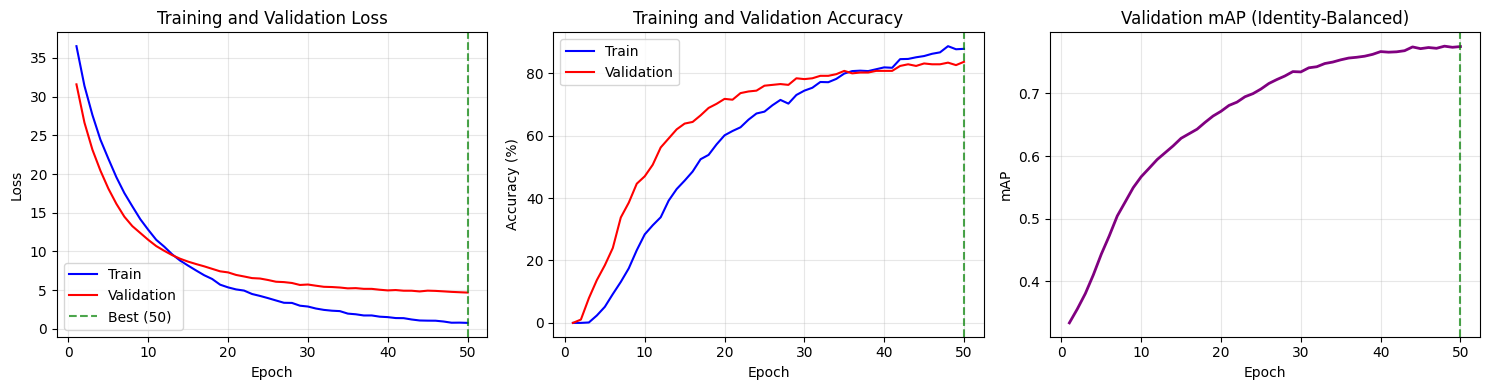

In [19]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7,
                label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mAP')
axes[2].set_title('Validation mAP (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'training_curves.png',
            dpi=150, bbox_inches='tight')
wandb.log({"training/curves": wandb.Image(fig)})
plt.show()


## 9. Reload Best Checkpoint

We explicitly reload the best checkpoint saved during training. This guarantees
that all subsequent TTA and AQE evaluation uses the best weights, not the
final-epoch weights (which may have overfit slightly).


In [20]:
# Guard: re-train if checkpoint is missing (e.g. after session restart)
if not CHECKPOINT_PATH.exists():
    print(f"Checkpoint not found at {CHECKPOINT_PATH} — running training now.")

    set_seed(config["seed"])
    model = ArcFaceModel(
        input_dim     = megadescriptor_dim,
        num_classes   = num_classes,
        embedding_dim = config["embedding_dim"],
        hidden_dim    = config["hidden_dim"],
        margin        = config["arcface_margin"],
        scale         = config["arcface_scale"],
        dropout       = config["dropout"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=config["learning_rate"],
                                   weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    history = {k: [] for k in
               ['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_map', 'lr']}
    best_val_loss    = float('inf')
    best_map         = 0.0
    best_epoch       = 0
    patience_counter = 0

    for epoch in range(config['num_epochs']):
        train_loss, train_acc = train_epoch(model, train_loader, criterion,
                                             optimizer, device)
        val_loss, val_acc     = validate_epoch(model, val_loader, criterion, device)
        val_map               = compute_validation_map(
                                    model, baseline_val_embeddings, val_labels_str)
        scheduler.step(val_loss)
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(
            ['train_loss','train_acc','val_loss','val_acc','val_map','lr'],
            [train_loss, train_acc, val_loss, val_acc, val_map, lr]):
            history[k].append(v)

        wandb.log({
            "training/epoch":      epoch + 1,
            "training/train_loss": train_loss,
            "training/train_acc":  train_acc,
            "training/val_loss":   val_loss,
            "training/val_acc":    val_acc,
            "training/val_map":    val_map,
            "training/lr":         lr,
        })

        print(f"  Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"TrLoss: {train_loss:.4f} | VaLoss: {val_loss:.4f} | "
              f"VamAP: {val_map:.4f} | LR: {lr:.2e}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_map         = val_map
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save({
                'epoch':              best_epoch,
                'model_state_dict':   model.state_dict(),
                'val_loss':           float(best_val_loss),
                'val_map':            float(best_map),
                'megadescriptor_dim': megadescriptor_dim,
                'num_classes':        num_classes,
                'config':             {k: str(v) if isinstance(v, Path) else v
                                       for k, v in config.items()},
            }, CHECKPOINT_PATH)
            print(f"    ✓ Saved checkpoint → {CHECKPOINT_PATH} "
                  f"(epoch {best_epoch}, mAP={best_map:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.log({
        "training/best_val_map":  best_map,
        "training/best_epoch":    best_epoch,
        "training/best_val_loss": best_val_loss,
    })
    print(f"\nTraining complete. Best mAP: {best_map:.4f} @ epoch {best_epoch}")
else:
    print(f"Checkpoint found at {CHECKPOINT_PATH} — skipping training.")


Checkpoint found at /kaggle/working/checkpoints/megadescriptor_arcface_best.pth — skipping training.


In [21]:
print(f"Reloading best checkpoint from: {CHECKPOINT_PATH}")
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

reid_model = ArcFaceModel(
    input_dim     = ckpt['megadescriptor_dim'],
    num_classes   = ckpt['num_classes'],
    embedding_dim = config["embedding_dim"],
    hidden_dim    = config["hidden_dim"],
    margin        = config["arcface_margin"],
    scale         = config["arcface_scale"],
    dropout       = config["dropout"],
).to(device)
reid_model.load_state_dict(ckpt['model_state_dict'])
reid_model.eval()
for p in reid_model.parameters():
    p.requires_grad = False

print(f"  Epoch:   {ckpt['epoch']}")
print(f"  val_map: {ckpt['val_map']:.4f}")
print(f"  val_loss:{ckpt['val_loss']:.4f}")
print(f"  All parameters frozen for inference.")

# Verify checkpoint mAP matches training log
reloaded_map = compute_validation_map(
    reid_model, baseline_val_embeddings, val_labels_str)
print(f"\nVerification — reloaded checkpoint mAP: {reloaded_map:.4f}")
assert abs(reloaded_map - ckpt['val_map']) < 0.001, (
    f"Checkpoint mAP mismatch: {reloaded_map:.4f} vs {ckpt['val_map']:.4f}")
print("Checkpoint verified ✓")


Reloading best checkpoint from: /kaggle/working/checkpoints/megadescriptor_arcface_best.pth
  Epoch:   50
  val_map: 0.7748
  val_loss:4.6852
  All parameters frozen for inference.

Verification — reloaded checkpoint mAP: 0.7748
Checkpoint verified ✓


## 10. Define TTA Augmentation Pipelines

We define 8 deterministic augmentation views ordered from least to most aggressive.
TTA-4 always uses the same first 4 views as TTA-8, keeping the ablation clean.

| View | Augmentation |
|---|---|
| 1 | Original (resize + normalize only) |
| 2 | Horizontal flip |
| 3 | Colour jitter (brightness, contrast, saturation ±0.2) |
| 4 | Random resized crop (scale 0.85–1.0) |
| 5 | Flip + colour jitter |
| 6 | Flip + crop |
| 7 | Aggressive colour jitter (±0.4, hue ±0.1) |
| 8 | Crop + aggressive colour jitter |


In [22]:
INPUT_SIZE = config["input_size"]
NORM = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])

def make_tta_transforms(n_views: int) -> list:
    """
    Return n_views deterministic transforms, ordered least to most aggressive.
    TTA-4 is always a strict subset of TTA-8.
    """
    resize = transforms.Resize((INPUT_SIZE, INPUT_SIZE))

    all_views = [
        transforms.Compose([resize, transforms.ToTensor(), NORM]),

        transforms.Compose([resize, transforms.RandomHorizontalFlip(p=1.0),
                             transforms.ToTensor(), NORM]),

        transforms.Compose([resize,
                             transforms.ColorJitter(
                                 brightness=0.2, contrast=0.2, saturation=0.2),
                             transforms.ToTensor(), NORM]),

        transforms.Compose([
            transforms.RandomResizedCrop(INPUT_SIZE,
                                          scale=(0.85, 1.0), ratio=(0.9, 1.1)),
            transforms.ToTensor(), NORM]),

        transforms.Compose([resize, transforms.RandomHorizontalFlip(p=1.0),
                             transforms.ColorJitter(
                                 brightness=0.2, contrast=0.2, saturation=0.2),
                             transforms.ToTensor(), NORM]),

        transforms.Compose([
            transforms.RandomResizedCrop(INPUT_SIZE,
                                          scale=(0.85, 1.0), ratio=(0.9, 1.1)),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(), NORM]),

        transforms.Compose([resize,
                             transforms.ColorJitter(
                                 brightness=0.4, contrast=0.4,
                                 saturation=0.4, hue=0.1),
                             transforms.ToTensor(), NORM]),

        transforms.Compose([
            transforms.RandomResizedCrop(INPUT_SIZE,
                                          scale=(0.8, 1.0), ratio=(0.85, 1.15)),
            transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                    saturation=0.4, hue=0.1),
            transforms.ToTensor(), NORM]),
    ]

    assert n_views <= len(all_views), (
        f"Only {len(all_views)} views defined, requested {n_views}")
    return all_views[:n_views]


for n in TTA_CONFIGS:
    print(f"  TTA-{n}: {len(make_tta_transforms(n))} transforms defined ✓")


  TTA-1: 1 transforms defined ✓
  TTA-4: 4 transforms defined ✓
  TTA-8: 8 transforms defined ✓


## 11. TTA Embedding Extraction and AQE

`extract_tta_embeddings` runs the frozen backbone + frozen head on N augmented
views of every image and returns the averaged, L2-normalised embedding.

`apply_aqe` then optionally refines each query by blending it toward its
top-k neighbours:
```
q_expanded = L2_norm( q + α × mean(top_k_neighbours(q)) )
```


In [23]:
@torch.no_grad()
def extract_tta_embeddings(backbone, reid_model, image_paths,
                            n_views: int, batch_size: int = 32,
                            desc: str = "") -> np.ndarray:
    """
    Extract TTA-averaged embeddings.
    For each image: apply n_views augmentations → backbone → head → mean → L2-norm.
    """
    backbone.eval(); reid_model.eval()
    tfms     = make_tta_transforms(n_views)
    all_embs = []

    for i in tqdm(range(0, len(image_paths), batch_size),
                  desc=desc or f"TTA-{n_views}"):
        batch_paths  = image_paths[i:i + batch_size]
        view_tensors = [[] for _ in range(n_views)]

        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
            except Exception as e:
                print(f"  [WARN] {path}: {e}")
                img = Image.new("RGB", (INPUT_SIZE, INPUT_SIZE))
            for v, tfm in enumerate(tfms):
                view_tensors[v].append(tfm(img))

        view_embs = []
        for v in range(n_views):
            batch  = torch.stack(view_tensors[v]).to(device)
            bb_emb = backbone(batch)
            proj   = reid_model.get_embeddings(bb_emb)
            view_embs.append(proj.cpu().numpy())

        avg = np.mean(np.stack(view_embs, axis=0), axis=0)
        avg = avg / (np.linalg.norm(avg, axis=1, keepdims=True) + 1e-12)
        all_embs.append(avg)

    return np.vstack(all_embs)


def apply_aqe(embeddings: np.ndarray, k: int, alpha: float) -> np.ndarray:
    """
    Average Query Expansion.
    q_expanded = L2_norm( q + alpha * mean(top_k_neighbours(q)) )
    k=0 or alpha=0 → no-op.
    """
    if k == 0 or alpha == 0.0:
        return embeddings
    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -1)
    expanded = np.empty_like(embeddings)
    for i in range(len(embeddings)):
        top_k       = np.argsort(-sim[i])[:k]
        top_k_mean  = embeddings[top_k].mean(axis=0)
        q_new       = embeddings[i] + alpha * top_k_mean
        expanded[i] = q_new / (np.linalg.norm(q_new) + 1e-12)
    return expanded


print("extract_tta_embeddings and apply_aqe defined.")


extract_tta_embeddings and apply_aqe defined.


## 12. Run Full Ablation

All (TTA views × AQE configs) combinations are evaluated on the validation set.
TTA embeddings for each view count are cached in memory to avoid re-extraction
when only the AQE config changes.


In [24]:
ablation_results = {}   # (n_views, k, alpha) -> result dict
tta_emb_cache    = {}   # n_views -> {"emb": ndarray, "extract_s": float}

print("=" * 65)
print("ABLATION: TTA views × AQE configs")
print("=" * 65)

for n_views in TTA_CONFIGS:

    # Extract TTA embeddings (or reuse cache)
    if n_views not in tta_emb_cache:
        print(f"\nExtracting TTA-{n_views} embeddings "
              f"for {len(val_paths)} val images...")
        t0  = time.perf_counter()
        emb = extract_tta_embeddings(
            megadescriptor, reid_model, val_paths,
            n_views    = n_views,
            batch_size = config["batch_size"],
            desc       = f"TTA-{n_views} val",
        )
        extract_s = time.perf_counter() - t0
        tta_emb_cache[n_views] = {"emb": emb, "extract_s": extract_s}
        print(f"  Shape: {emb.shape}  |  Time: {extract_s:.1f}s")
    else:
        print(f"\nTTA-{n_views}: reusing cached embeddings")

    base_emb  = tta_emb_cache[n_views]["emb"]
    extract_s = tta_emb_cache[n_views]["extract_s"]

    # Apply each AQE config
    for aqe_cfg in AQE_CONFIGS:
        k, alpha = aqe_cfg["k"], aqe_cfg["alpha"]
        label    = (f"TTA-{n_views}_AQE-k{k}"
                    if k > 0 else f"TTA-{n_views}_NoAQE")

        t_aqe  = time.perf_counter()
        emb_aq = apply_aqe(base_emb, k=k, alpha=alpha)
        aqe_s  = time.perf_counter() - t_aqe

        val_map = _map_from_embeddings(emb_aq, val_labels_str)
        total_s = extract_s + aqe_s

        ablation_results[(n_views, k, alpha)] = {
            "label":     label,
            "n_views":   n_views,
            "k":         k,
            "alpha":     alpha,
            "map":       val_map,
            "extract_s": extract_s,
            "aqe_s":     aqe_s,
            "total_s":   total_s,
            "emb":       emb_aq,
        }

        wandb.log({
            f"{label}/val_map":  val_map,
            f"{label}/total_s":  total_s,
            f"{label}/n_views":  n_views,
            f"{label}/aqe_k":    k,
        })

        print(f"  {label:35s} | mAP={val_map:.4f} | "
              f"time={total_s:.1f}s "
              f"(extract={extract_s:.1f}s + AQE={aqe_s:.2f}s)")

print("\n" + "=" * 65)
print("ABLATION COMPLETE")
print("=" * 65)


ABLATION: TTA views × AQE configs

Extracting TTA-1 embeddings for 379 val images...


TTA-1 val:   0%|          | 0/12 [00:00<?, ?it/s]

  Shape: (379, 256)  |  Time: 160.1s
  TTA-1_NoAQE                         | mAP=0.7748 | time=160.1s (extract=160.1s + AQE=0.00s)
  TTA-1_AQE-k5                        | mAP=0.7713 | time=160.1s (extract=160.1s + AQE=0.02s)
  TTA-1_AQE-k10                       | mAP=0.7638 | time=160.1s (extract=160.1s + AQE=0.02s)

Extracting TTA-4 embeddings for 379 val images...


TTA-4 val:   0%|          | 0/12 [00:00<?, ?it/s]

  Shape: (379, 256)  |  Time: 313.4s
  TTA-4_NoAQE                         | mAP=0.7755 | time=313.4s (extract=313.4s + AQE=0.00s)
  TTA-4_AQE-k5                        | mAP=0.7760 | time=313.4s (extract=313.4s + AQE=0.02s)
  TTA-4_AQE-k10                       | mAP=0.7596 | time=313.4s (extract=313.4s + AQE=0.02s)

Extracting TTA-8 embeddings for 379 val images...


TTA-8 val:   0%|          | 0/12 [00:00<?, ?it/s]

  Shape: (379, 256)  |  Time: 522.0s
  TTA-8_NoAQE                         | mAP=0.7696 | time=522.0s (extract=522.0s + AQE=0.00s)
  TTA-8_AQE-k5                        | mAP=0.7728 | time=522.1s (extract=522.0s + AQE=0.02s)
  TTA-8_AQE-k10                       | mAP=0.7424 | time=522.1s (extract=522.0s + AQE=0.02s)

ABLATION COMPLETE


## 13. Results and Analysis

In [25]:
baseline_key = (1, 0, 0.0)
baseline_map = ablation_results[baseline_key]["map"]
sorted_results = sorted(ablation_results.values(), key=lambda r: -r["map"])
best_result    = sorted_results[0]

print("=" * 72)
print(f"{'Condition':35s} | {'mAP':>6} | {'vs Baseline':>11} | {'Time (s)':>8}")
print("-" * 72)
for r in sorted_results:
    gain   = r["map"] - baseline_map
    marker = "  << BEST"     if r == best_result else ""
    note   = "  (baseline)"  if r["n_views"] == 1 and r["k"] == 0 else ""
    print(f"  {r['label']:33s} | {r['map']:.4f} | "
          f"{gain:+.4f}     | {r['total_s']:>7.1f}s{marker}{note}")
print("=" * 72)

print(f"\nCheckpoint mAP (single-pass, trained model): {ckpt['val_map']:.4f}")
print(f"Baseline (TTA-1, no AQE):                    {baseline_map:.4f}")
print(f"Best condition ({best_result['label']}):  {best_result['map']:.4f}")
print(f"Gain over baseline:                          "
      f"{best_result['map'] - baseline_map:+.4f}")
print(f"Gain over checkpoint:                        "
      f"{best_result['map'] - ckpt['val_map']:+.4f}")

wandb.log({
    "results/checkpoint_map": float(ckpt['val_map']),
    "results/baseline_map":   baseline_map,
    "results/best_map":       best_result["map"],
    "results/best_condition": best_result["label"],
    "results/gain_over_baseline":   best_result["map"] - baseline_map,
    "results/gain_over_checkpoint": best_result["map"] - ckpt["val_map"],
})


Condition                           |    mAP | vs Baseline | Time (s)
------------------------------------------------------------------------
  TTA-4_AQE-k5                      | 0.7760 | +0.0012     |   313.4s  << BEST
  TTA-4_NoAQE                       | 0.7755 | +0.0007     |   313.4s
  TTA-1_NoAQE                       | 0.7748 | +0.0000     |   160.1s  (baseline)
  TTA-8_AQE-k5                      | 0.7728 | -0.0021     |   522.1s
  TTA-1_AQE-k5                      | 0.7713 | -0.0036     |   160.1s
  TTA-8_NoAQE                       | 0.7696 | -0.0052     |   522.0s
  TTA-1_AQE-k10                     | 0.7638 | -0.0111     |   160.1s
  TTA-4_AQE-k10                     | 0.7596 | -0.0152     |   313.4s
  TTA-8_AQE-k10                     | 0.7424 | -0.0325     |   522.1s

Checkpoint mAP (single-pass, trained model): 0.7748
Baseline (TTA-1, no AQE):                    0.7748
Best condition (TTA-4_AQE-k5):  0.7760
Gain over baseline:                          +0.0012
Gain over

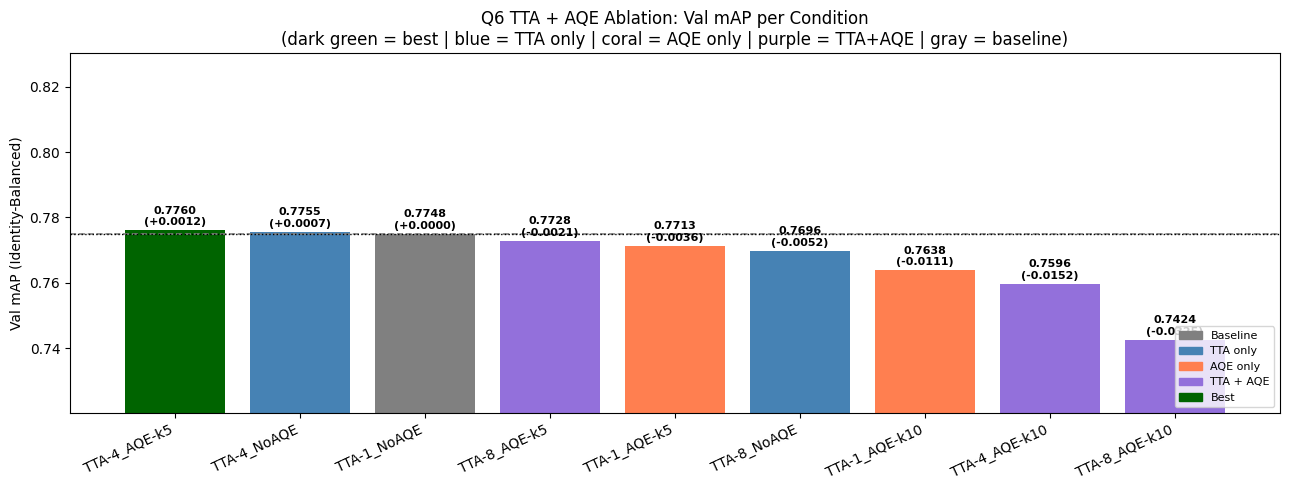

In [26]:
labels = [r["label"] for r in sorted_results]
maps   = [r["map"]   for r in sorted_results]

colors = []
for r in sorted_results:
    if r == best_result:                          colors.append("darkgreen")
    elif r["n_views"] == 1 and r["k"] == 0:      colors.append("gray")
    elif r["k"] > 0 and r["n_views"] > 1:        colors.append("mediumpurple")
    elif r["k"] > 0:                             colors.append("coral")
    else:                                         colors.append("steelblue")

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, maps, color=colors)
for bar, val, r in zip(bars, maps, sorted_results):
    gain = val - baseline_map
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{val:.4f}\n({gain:+.4f})",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=baseline_map, color='gray', linestyle='--', linewidth=1.2,
           label=f"Baseline (TTA-1, no AQE): {baseline_map:.4f}")
ax.axhline(y=ckpt['val_map'], color='black', linestyle=':', linewidth=1.0,
           label=f"Checkpoint mAP: {ckpt['val_map']:.4f}")
ax.set_ylim(min(maps) * 0.97, max(maps) * 1.07)
ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('TTA + AQE Ablation: Val mAP per Condition\n'
             '(dark green = best | blue = TTA only | '
             'coral = AQE only | purple = TTA+AQE | gray = baseline)')

legend_patches = [
    mpatches.Patch(color='gray',         label='Baseline'),
    mpatches.Patch(color='steelblue',    label='TTA only'),
    mpatches.Patch(color='coral',        label='AQE only'),
    mpatches.Patch(color='mediumpurple', label='TTA + AQE'),
    mpatches.Patch(color='darkgreen',    label='Best'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
wandb.log({"results/ablation_bar_chart": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'tta_aqe_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()


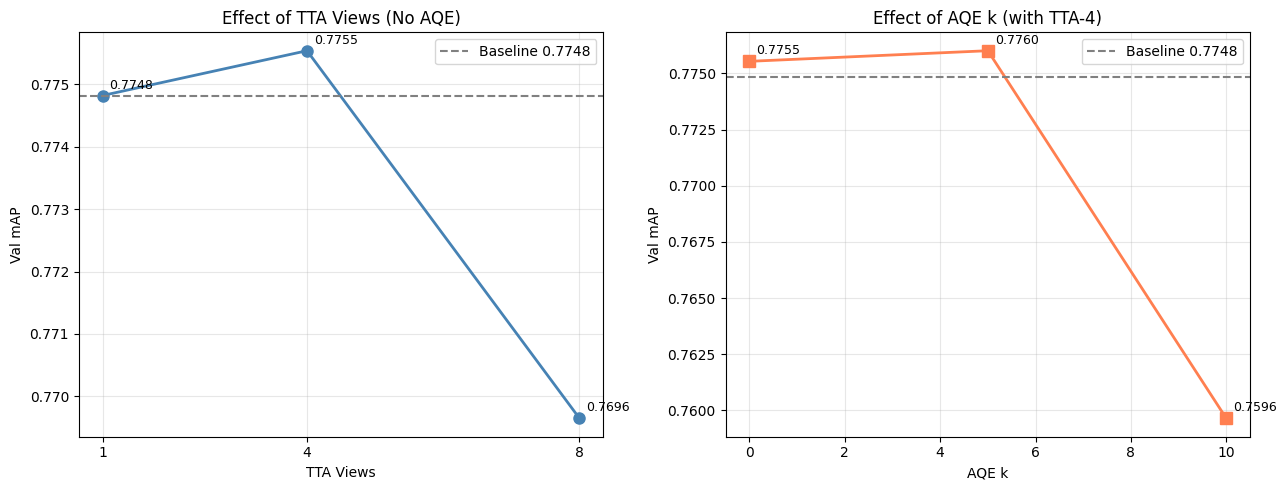

In [27]:
# TTA views effect (no AQE) vs AQE k effect (best TTA)
tta_only_maps = [ablation_results[(n, 0, 0.0)]["map"] for n in TTA_CONFIGS]
best_n        = best_result["n_views"]
aqe_ks        = [c["k"] for c in AQE_CONFIGS]
aqe_maps      = [ablation_results[(best_n, c["k"], c["alpha"])]["map"]
                 for c in AQE_CONFIGS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(TTA_CONFIGS, tta_only_maps, 'o-', color='steelblue',
             linewidth=2, markersize=8)
for n, m in zip(TTA_CONFIGS, tta_only_maps):
    axes[0].annotate(f"{m:.4f}", (n, m),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].axhline(y=baseline_map, color='gray', linestyle='--',
                label=f"Baseline {baseline_map:.4f}")
axes[0].set_xlabel('TTA Views'); axes[0].set_ylabel('Val mAP')
axes[0].set_title('Effect of TTA Views (No AQE)')
axes[0].set_xticks(TTA_CONFIGS); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(aqe_ks, aqe_maps, 's-', color='coral', linewidth=2, markersize=8)
for k, m in zip(aqe_ks, aqe_maps):
    axes[1].annotate(f"{m:.4f}", (k, m),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].axhline(y=baseline_map, color='gray', linestyle='--',
                label=f"Baseline {baseline_map:.4f}")
axes[1].set_xlabel('AQE k'); axes[1].set_ylabel('Val mAP')
axes[1].set_title(f'Effect of AQE k (with TTA-{best_n})')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
wandb.log({"results/tta_aqe_line_charts": wandb.Image(fig)})
plt.show()


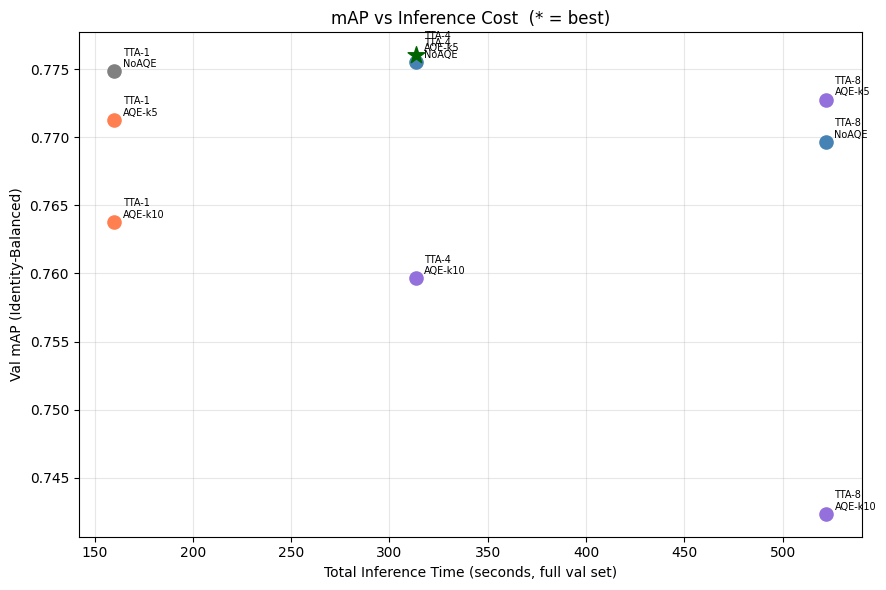

In [28]:
fig, ax = plt.subplots(figsize=(9, 6))
for r in ablation_results.values():
    is_best = r == best_result
    is_base = r["n_views"] == 1 and r["k"] == 0
    color   = ("darkgreen"    if is_best else
                "gray"         if is_base else
                "mediumpurple" if r["k"] > 0 and r["n_views"] > 1 else
                "coral"        if r["k"] > 0 else "steelblue")
    ax.scatter(r["total_s"], r["map"], s=160 if is_best else 90,
               color=color, zorder=3, marker="*" if is_best else "o")
    ax.annotate(r["label"].replace("_", "\n"),
                (r["total_s"], r["map"]),
                textcoords='offset points', xytext=(6, 3), fontsize=7)
ax.set_xlabel('Total Inference Time (seconds, full val set)')
ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('mAP vs Inference Cost  (* = best)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"results/map_vs_time_scatter": wandb.Image(fig)})
plt.show()


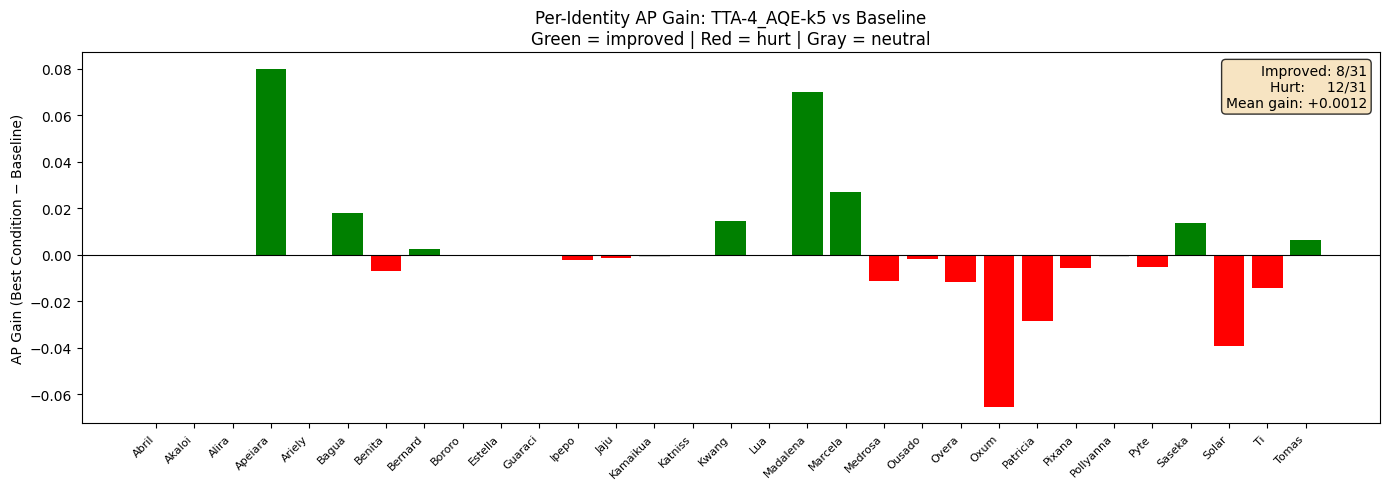

In [29]:
def per_identity_ap(embeddings, labels):
    emb = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return {k: float(np.mean(v)) for k, v in id_aps.items()}


baseline_per_id = per_identity_ap(
    ablation_results[baseline_key]["emb"], val_labels_str)
best_per_id     = per_identity_ap(best_result["emb"], val_labels_str)

identities = sorted(best_per_id.keys())
gains       = [best_per_id[i] - baseline_per_id.get(i, 0.0) for i in identities]
n_improved  = sum(1 for g in gains if g > 0.001)
n_hurt      = sum(1 for g in gains if g < -0.001)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['green' if g > 0.001 else 'red' if g < -0.001 else 'lightgray'
           for g in gains]
ax.bar(range(len(identities)), gains, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(identities)))
ax.set_xticklabels(identities, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AP Gain (Best Condition − Baseline)')
ax.set_title(f'Per-Identity AP Gain: {best_result["label"]} vs Baseline\n'
             f'Green = improved | Red = hurt | Gray = neutral')
ax.text(0.99, 0.97,
        f'Improved: {n_improved}/{len(identities)}\n'
        f'Hurt:     {n_hurt}/{len(identities)}\n'
        f'Mean gain: {np.mean(gains):+.4f}',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
wandb.log({"results/per_identity_gain": wandb.Image(fig)})
plt.show()

wandb.log({
    "results/identities_improved": n_improved,
    "results/identities_hurt":     n_hurt,
    "results/mean_per_id_gain":    float(np.mean(gains)),
})


In [30]:
# Are TTA and AQE gains additive?
best_tta_key = max(
    [(n, 0, 0.0) for n in TTA_CONFIGS],
    key=lambda k: ablation_results[k]["map"])
best_aqe_key = max(
    [(1, c["k"], c["alpha"]) for c in AQE_CONFIGS if c["k"] > 0],
    key=lambda k: ablation_results[k]["map"])
best_comb_key = max(
    [(n, c["k"], c["alpha"])
     for n in TTA_CONFIGS for c in AQE_CONFIGS if c["k"] > 0],
    key=lambda k: ablation_results[k]["map"])

tta_map   = ablation_results[best_tta_key]["map"]
aqe_map   = ablation_results[best_aqe_key]["map"]
comb_map  = ablation_results[best_comb_key]["map"]
additive  = baseline_map + (tta_map - baseline_map) + (aqe_map - baseline_map)
interaction = comb_map - additive

print("Additivity analysis:")
print(f"  Baseline:               {baseline_map:.4f}")
print(f"  Best TTA (no AQE):      {tta_map:.4f}  "
      f"(+{tta_map - baseline_map:.4f})")
print(f"  Best AQE (TTA-1):       {aqe_map:.4f}  "
      f"(+{aqe_map - baseline_map:.4f})")
print(f"  Best TTA + AQE:         {comb_map:.4f}  "
      f"(+{comb_map - baseline_map:.4f})")
print(f"  Additive prediction:    {additive:.4f}")
print(f"  Interaction effect:     {interaction:+.4f}  "
      f"({'super-additive ✓' if interaction > 0 else 'sub-additive'})")

wandb.log({
    "additivity/tta_gain":      tta_map  - baseline_map,
    "additivity/aqe_gain":      aqe_map  - baseline_map,
    "additivity/combined_gain": comb_map - baseline_map,
    "additivity/interaction":   interaction,
})


Additivity analysis:
  Baseline:               0.7748
  Best TTA (no AQE):      0.7755  (+0.0007)
  Best AQE (TTA-1):       0.7713  (+-0.0036)
  Best TTA + AQE:         0.7760  (+0.0012)
  Additive prediction:    0.7720
  Interaction effect:     +0.0040  (super-additive ✓)


## 14. Generate Competition Submission

In [31]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(
    set(test_pairs_df['query_image'].unique()) |
    set(test_pairs_df['gallery_image'].unique()))
test_paths = [config["data_dir"] / "test/test" / fn for fn in test_images]

print(f"Test pairs:     {len(test_pairs_df)}")
print(f"Unique images:  {len(test_images)}")
print(f"Best condition: {best_result['label']}  "
      f"(TTA-{best_result['n_views']}, AQE k={best_result['k']})")

# Extract test embeddings with best TTA
print(f"\nExtracting test embeddings with TTA-{best_result['n_views']}...")
test_emb = extract_tta_embeddings(
    megadescriptor, reid_model, test_paths,
    n_views    = best_result["n_views"],
    batch_size = config["batch_size"],
    desc       = f"TTA-{best_result['n_views']} test",
)
print(f"Test embeddings: {test_emb.shape}")

# Apply best AQE
if best_result["k"] > 0:
    print(f"Applying AQE k={best_result['k']}, alpha={best_result['alpha']}...")
    test_emb = apply_aqe(test_emb, k=best_result["k"],
                          alpha=best_result["alpha"])

test_emb   = test_emb / (np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12)
img_to_emb = dict(zip(test_images, test_emb))


Test pairs:     137270
Unique images:  371
Best condition: TTA-4_AQE-k5  (TTA-4, AQE k=5)

Extracting test embeddings with TTA-4...


TTA-4 test:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: (371, 256)
Applying AQE k=5, alpha=1.0...


In [32]:
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df),
                   desc="Computing similarities"):
    q = img_to_emb[row['query_image']]
    g = img_to_emb[row['gallery_image']]
    similarities.append(float(np.dot(q, g)))

similarities = np.clip(np.array(similarities), 0.0, 1.0)
print(f"Similarity stats: min={similarities.min():.4f}  "
      f"max={similarities.max():.4f}  mean={similarities.mean():.4f}")

submission_df = pd.DataFrame({'row_id':     test_pairs_df['row_id'],
                               'similarity': similarities})
submission_path = config['checkpoint_dir'] / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved: {submission_path}")
print(submission_df.head(10))


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]

Similarity stats: min=0.0000  max=0.9990  mean=0.0711
Submission saved: /kaggle/working/checkpoints/submission.csv
   row_id  similarity
0       0    0.908200
1       1    0.080177
2       2    0.000000
3       3    0.018076
4       4    0.031107
5       5    0.000000
6       6    0.091052
7       7    0.000000
8       8    0.000000
9       9    0.056219


## 15. Save Artifacts to W&B

In [33]:
# Ablation results table
rows = []
for r in sorted(ablation_results.values(), key=lambda x: -x["map"]):
    rows.append({
        "condition":         r["label"],
        "n_tta_views":       r["n_views"],
        "aqe_k":             r["k"],
        "aqe_alpha":         r["alpha"],
        "val_map":           round(r["map"], 6),
        "gain_vs_baseline":  round(r["map"] - baseline_map, 6),
        "inference_s":       round(r["total_s"], 2),
    })
wandb.log({"results/ablation_table": wandb.Table(dataframe=pd.DataFrame(rows))})

# Model checkpoint artifact
model_art = wandb.Artifact("arcface-tta-aqe-model", type="model",
    description="MegaDescriptor + ArcFace head — best checkpoint")
model_art.add_file(str(CHECKPOINT_PATH))
wandb.log_artifact(model_art)

# Submission artifact
sub_art = wandb.Artifact("submission", type="submission",
    description=f"TTA+AQE submission | {best_result['label']}")
sub_art.add_file(str(submission_path))
wandb.log_artifact(sub_art)

wandb.finish()
print("W&B run completed.")
print(f"Checkpoint saved at: {CHECKPOINT_PATH}")


TTA-1_AQE-k10/aqe_k,▁
TTA-1_AQE-k10/n_views,▁
TTA-1_AQE-k10/total_s,▁
TTA-1_AQE-k10/val_map,▁
TTA-1_AQE-k5/aqe_k,▁
TTA-1_AQE-k5/n_views,▁
TTA-1_AQE-k5/total_s,▁
TTA-1_AQE-k5/val_map,▁
TTA-1_NoAQE/aqe_k,▁
TTA-1_NoAQE/n_views,▁
+51,...


W&B run completed.
Checkpoint saved at: /kaggle/working/checkpoints/megadescriptor_arcface_best.pth
